# Differential Gene Expression Analysis in Fatal COVID-19

## Introduction

Gene expression analysis provides a way to investigate how biological activity differs between experimental or clinical conditions.

In this project, RNA sequencing data from human tissue samples associated with fatal COVID-19 will be analysed to investigate differences in gene expression between COVID-19 cases and healthy controls.

The dataset is derived from the E-ENAD-46 study, which profiled lung and colon tissue from individuals who died from severe COVID-19 alongside healthy control samples.

The analysis will focus on the gene-expression data and will use Python to perform data inspection, preprocessing, exploratory analysis and statistical testing.

Because RNA-seq data are high-dimensional, thousands of genes may be tested simultaneously. The analysis will therefore consider both the magnitude of expression differences and the problem of multiple statistical comparisons.

This project is intended as an educational bioinformatics analysis rather than a clinical or diagnostic study.

## Objectives

The objectives of this analysis are to:

1. Inspect and understand the structure of the RNA-seq expression dataset.
2. Examine the available sample metadata and identify relevant comparison groups.
3. Preprocess the gene-expression measurements for exploratory analysis.
4. Compare gene-expression patterns between COVID-19 and control samples.
5. Quantify differences in gene expression using fold changes and statistical testing.
6. Apply multiple-testing correction when assessing gene-level statistical significance.
7. Visualise major patterns in the transcriptomic data.
8. Interpret the findings in a biological context while considering the limitations of the dataset and analytical approach.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 20)

In [2]:
import os

os.listdir("data")

['.DS_Store',
 'E-ENAD-46.g3_g1.go.gsea.tsv',
 'E-ENAD-46.g4_g2.reactome.gsea.tsv',
 'E-ENAD-46.condensed-sdrf.tsv',
 'E-ENAD-46.idf.txt',
 'E-ENAD-46-raw-counts.tsv']

In [3]:
counts_path = "data/E-ENAD-46-raw-counts.tsv"

counts = pd.read_csv(
    counts_path,
    sep="\t"
)

counts.head()

,Gene ID,Gene Name,SRR12816718,SRR12816719,SRR12816720,SRR12816721,SRR12816722,SRR12816723,SRR12816724,SRR12816725,SRR12816726,SRR12816727,SRR12816728,SRR12816729,SRR12816730,SRR12816731,SRR12816732,SRR12816733,SRR12816734,SRR12816735,SRR12816736,SRR12951211,SRR12951212,SRR12951213,SRR12951214,SRR12951215,SRR12951216,SRR12951217,SRR12951218,SRR12951219,SRR12951220,SRR12951221,SRR12951222,SRR12951223,SRR12951224,SRR12951225,SRR12951226,SRR12951227,SRR12951228,SRR12951229
0,ENSG00000000003,TSPAN6,245,369,331,380,704,138,713,1051,574,537,234,169,624,289,2980,475,444,14,169,512,1608,201,84,99,695,10,71,303,1559,934,1044,1196,391,1130,550,326,568,464
1,ENSG00000000005,TNMD,6,28,45,1,0,3,4,2,9,35,66,14,48,21,0,15,2,0,0,5,0,6,0,2,1,0,0,11,1,26,8,19,5,13,18,2,23,8
2,ENSG00000000419,DPM1,195,260,133,332,647,321,822,708,298,125,427,219,351,207,526,257,344,14,619,315,66,593,343,151,458,39,377,364,489,369,288,405,311,368,281,252,271,168
3,ENSG00000000457,SCYL3,216,245,38,109,385,163,207,394,312,384,517,289,568,279,344,366,322,209,325,270,179,428,194,155,822,79,277,267,495,351,387,534,235,595,491,396,365,325
4,ENSG00000000460,C1orf112,234,131,82,87,179,62,181,182,357,119,760,154,220,198,909,224,237,44,317,240,49,207,51,86,235,32,64,136,187,210,226,302,204,404,349,376,261,215


In [4]:
counts.shape

(58735, 40)

In [5]:
counts.columns.tolist()

['Gene ID',
 'Gene Name',
 'SRR12816718',
 'SRR12816719',
 'SRR12816720',
 'SRR12816721',
 'SRR12816722',
 'SRR12816723',
 'SRR12816724',
 'SRR12816725',
 'SRR12816726',
 'SRR12816727',
 'SRR12816728',
 'SRR12816729',
 'SRR12816730',
 'SRR12816731',
 'SRR12816732',
 'SRR12816733',
 'SRR12816734',
 'SRR12816735',
 'SRR12816736',
 'SRR12951211',
 'SRR12951212',
 'SRR12951213',
 'SRR12951214',
 'SRR12951215',
 'SRR12951216',
 'SRR12951217',
 'SRR12951218',
 'SRR12951219',
 'SRR12951220',
 'SRR12951221',
 'SRR12951222',
 'SRR12951223',
 'SRR12951224',
 'SRR12951225',
 'SRR12951226',
 'SRR12951227',
 'SRR12951228',
 'SRR12951229']

In [6]:
with open("data/E-ENAD-46.condensed-sdrf.tsv", "r", encoding="utf-8") as f:
    for i in range(10):
        print(repr(f.readline()))

'E-ENAD-46\t\tSRR12816718\tcharacteristic\tage\tnot available\n'
'E-ENAD-46\t\tSRR12816718\tcharacteristic\tbiosource provider\tGuoping Wang Lab, Department of Pathology, School of Basic Medicine, Tongji Medical College, Huazhong University of Science and Technology\n'
'E-ENAD-46\t\tSRR12816718\tcharacteristic\tdisease\tnormal\thttp://purl.obolibrary.org/obo/PATO_0000461\n'
'E-ENAD-46\t\tSRR12816718\tcharacteristic\tindividual\tWuhan_control_1\n'
'E-ENAD-46\t\tSRR12816718\tcharacteristic\torganism\tHomo sapiens\thttp://purl.obolibrary.org/obo/NCBITaxon_9606\n'
'E-ENAD-46\t\tSRR12816718\tcharacteristic\torganism part\tlung\thttp://purl.obolibrary.org/obo/UBERON_0002048\n'
'E-ENAD-46\t\tSRR12816718\tcharacteristic\tsex\tnot available\n'
'E-ENAD-46\t\tSRR12816718\tcharacteristic\tspecimen with known storage state\tparaffin specimen\thttp://purl.obolibrary.org/obo/OBI_0000950\n'
'E-ENAD-46\t\tSRR12816718\tfactor\tdisease\tnormal\thttp://purl.obolibrary.org/obo/PATO_0000461\n'
'E-ENAD-46\t\

In [7]:
metadata = pd.read_csv(
    "data/E-ENAD-46.condensed-sdrf.tsv",
    sep="\t",
    header=None,
    names=[
        "study",
        "sample",
        "run",
        "record_type",
        "attribute",
        "value",
        "ontology"
    ],
    engine="python"
)

metadata.head(10)

,study,sample,run,record_type,attribute,value,ontology
0,E-ENAD-46,NaN,SRR12816718,characteristic,age,not available,None
1,E-ENAD-46,NaN,SRR12816718,characteristic,biosource provider,"Guoping Wang Lab, Department of Pathology, Sch...",None
2,E-ENAD-46,NaN,SRR12816718,characteristic,disease,normal,http://purl.obolibrary.org/obo/PATO_0000461
3,E-ENAD-46,NaN,SRR12816718,characteristic,individual,Wuhan_control_1,None
4,E-ENAD-46,NaN,SRR12816718,characteristic,organism,Homo sapiens,http://purl.obolibrary.org/obo/NCBITaxon_9606
5,E-ENAD-46,NaN,SRR12816718,characteristic,organism part,lung,http://purl.obolibrary.org/obo/UBERON_0002048
6,E-ENAD-46,NaN,SRR12816718,characteristic,sex,not available,None
7,E-ENAD-46,NaN,SRR12816718,characteristic,specimen with known storage state,paraffin specimen,http://purl.obolibrary.org/obo/OBI_0000950
8,E-ENAD-46,NaN,SRR12816718,factor,disease,normal,http://purl.obolibrary.org/obo/PATO_0000461
9,E-ENAD-46,NaN,SRR12816718,factor,organism part,lung,http://purl.obolibrary.org/obo/UBERON_0002048


In [8]:
metadata.shape

(380, 7)

In [9]:
metadata.columns

Index(['study', 'sample', 'run', 'record_type', 'attribute', 'value',
       'ontology'],
      dtype='object')

In [10]:
metadata["attribute"].value_counts()

attribute
disease                              76
organism part                        76
age                                  38
biosource provider                   38
individual                           38
organism                             38
sex                                  38
specimen with known storage state    38
Name: count, dtype: int64

In [11]:
metadata.loc[
    metadata["attribute"] == "disease",
    ["sample", "run", "value"]
].head(20)

,sample,run,value
2,NaN,SRR12816718,normal
8,NaN,SRR12816718,normal
12,NaN,SRR12816719,COVID-19
18,NaN,SRR12816719,COVID-19
22,NaN,SRR12816720,COVID-19
28,NaN,SRR12816720,COVID-19
32,NaN,SRR12816721,COVID-19
38,NaN,SRR12816721,COVID-19
42,NaN,SRR12816722,COVID-19
48,NaN,SRR12816722,COVID-19


In [12]:
metadata.loc[
    metadata["attribute"] == "organism part",
    ["sample", "run", "value"]
].head(20)

,sample,run,value
5,NaN,SRR12816718,lung
9,NaN,SRR12816718,lung
15,NaN,SRR12816719,lung
19,NaN,SRR12816719,lung
25,NaN,SRR12816720,lung
29,NaN,SRR12816720,lung
35,NaN,SRR12816721,lung
39,NaN,SRR12816721,lung
45,NaN,SRR12816722,lung
49,NaN,SRR12816722,lung


In [13]:
disease_metadata = metadata[
    (metadata["record_type"] == "factor") &
    (metadata["attribute"] == "disease")
][["run", "value"]].copy()

disease_metadata = disease_metadata.rename(
    columns={"value": "disease"}
)

disease_metadata

,run,disease
8,SRR12816718,normal
18,SRR12816719,COVID-19
28,SRR12816720,COVID-19
38,SRR12816721,COVID-19
48,SRR12816722,COVID-19
...,...,...
338,SRR12951225,normal
348,SRR12951226,normal
358,SRR12951227,normal
368,SRR12951228,normal


In [14]:
disease_metadata.shape

(38, 2)

In [15]:
disease_metadata["disease"].value_counts()

disease
normal      20
COVID-19    18
Name: count, dtype: int64

In [16]:
disease_metadata["run"].nunique()

38

In [17]:
tissue_metadata = metadata[
    (metadata["record_type"] == "factor") &
    (metadata["attribute"] == "organism part")
][["run", "value"]].copy()

tissue_metadata = tissue_metadata.rename(
    columns={"value": "tissue"}
)

tissue_metadata.head()

,run,tissue
9,SRR12816718,lung
19,SRR12816719,lung
29,SRR12816720,lung
39,SRR12816721,lung
49,SRR12816722,lung


In [18]:
sample_metadata = disease_metadata.merge(
    tissue_metadata,
    on="run",
    how="inner"
)

sample_metadata.head()

,run,disease,tissue
0,SRR12816718,normal,lung
1,SRR12816719,COVID-19,lung
2,SRR12816720,COVID-19,lung
3,SRR12816721,COVID-19,lung
4,SRR12816722,COVID-19,lung


In [19]:
sample_metadata.shape

(38, 3)

In [20]:
sample_metadata["tissue"].value_counts()

tissue
lung     19
colon    19
Name: count, dtype: int64

In [21]:
sample_metadata["disease"].value_counts()

disease
normal      20
COVID-19    18
Name: count, dtype: int64

In [22]:
pd.crosstab(
    sample_metadata["tissue"],
    sample_metadata["disease"]
)

disease,COVID-19,normal
tissue,,
colon,9,10
lung,9,10


In [23]:
lung_metadata = sample_metadata[
    sample_metadata["tissue"] == "lung"
].copy()

lung_metadata

,run,disease,tissue
0,SRR12816718,normal,lung
1,SRR12816719,COVID-19,lung
2,SRR12816720,COVID-19,lung
3,SRR12816721,COVID-19,lung
4,SRR12816722,COVID-19,lung
5,SRR12816723,COVID-19,lung
6,SRR12816724,COVID-19,lung
7,SRR12816725,COVID-19,lung
8,SRR12816726,normal,lung
9,SRR12816727,normal,lung


In [24]:
lung_metadata["disease"].value_counts()

disease
normal      10
COVID-19     9
Name: count, dtype: int64

In [25]:
counts.shape

(58735, 40)

In [26]:
counts.head()

,Gene ID,Gene Name,SRR12816718,SRR12816719,SRR12816720,SRR12816721,SRR12816722,SRR12816723,SRR12816724,SRR12816725,SRR12816726,SRR12816727,SRR12816728,SRR12816729,SRR12816730,SRR12816731,SRR12816732,SRR12816733,SRR12816734,SRR12816735,SRR12816736,SRR12951211,SRR12951212,SRR12951213,SRR12951214,SRR12951215,SRR12951216,SRR12951217,SRR12951218,SRR12951219,SRR12951220,SRR12951221,SRR12951222,SRR12951223,SRR12951224,SRR12951225,SRR12951226,SRR12951227,SRR12951228,SRR12951229
0,ENSG00000000003,TSPAN6,245,369,331,380,704,138,713,1051,574,537,234,169,624,289,2980,475,444,14,169,512,1608,201,84,99,695,10,71,303,1559,934,1044,1196,391,1130,550,326,568,464
1,ENSG00000000005,TNMD,6,28,45,1,0,3,4,2,9,35,66,14,48,21,0,15,2,0,0,5,0,6,0,2,1,0,0,11,1,26,8,19,5,13,18,2,23,8
2,ENSG00000000419,DPM1,195,260,133,332,647,321,822,708,298,125,427,219,351,207,526,257,344,14,619,315,66,593,343,151,458,39,377,364,489,369,288,405,311,368,281,252,271,168
3,ENSG00000000457,SCYL3,216,245,38,109,385,163,207,394,312,384,517,289,568,279,344,366,322,209,325,270,179,428,194,155,822,79,277,267,495,351,387,534,235,595,491,396,365,325
4,ENSG00000000460,C1orf112,234,131,82,87,179,62,181,182,357,119,760,154,220,198,909,224,237,44,317,240,49,207,51,86,235,32,64,136,187,210,226,302,204,404,349,376,261,215


In [27]:
counts.columns.tolist()

['Gene ID',
 'Gene Name',
 'SRR12816718',
 'SRR12816719',
 'SRR12816720',
 'SRR12816721',
 'SRR12816722',
 'SRR12816723',
 'SRR12816724',
 'SRR12816725',
 'SRR12816726',
 'SRR12816727',
 'SRR12816728',
 'SRR12816729',
 'SRR12816730',
 'SRR12816731',
 'SRR12816732',
 'SRR12816733',
 'SRR12816734',
 'SRR12816735',
 'SRR12816736',
 'SRR12951211',
 'SRR12951212',
 'SRR12951213',
 'SRR12951214',
 'SRR12951215',
 'SRR12951216',
 'SRR12951217',
 'SRR12951218',
 'SRR12951219',
 'SRR12951220',
 'SRR12951221',
 'SRR12951222',
 'SRR12951223',
 'SRR12951224',
 'SRR12951225',
 'SRR12951226',
 'SRR12951227',
 'SRR12951228',
 'SRR12951229']

In [28]:
lung_samples = lung_metadata["run"].tolist()

lung_samples

['SRR12816718',
 'SRR12816719',
 'SRR12816720',
 'SRR12816721',
 'SRR12816722',
 'SRR12816723',
 'SRR12816724',
 'SRR12816725',
 'SRR12816726',
 'SRR12816727',
 'SRR12816728',
 'SRR12816729',
 'SRR12816730',
 'SRR12816731',
 'SRR12816732',
 'SRR12816733',
 'SRR12816734',
 'SRR12816735',
 'SRR12816736']

In [29]:
set(lung_samples).issubset(counts.columns)

True

In [30]:
lung_counts = counts[
    ["Gene ID", "Gene Name"] + lung_samples
].copy()

lung_counts.shape

(58735, 21)

In [31]:
lung_counts["Gene ID"].duplicated().sum()

np.int64(0)

In [32]:
lung_counts["Gene Name"].duplicated().sum()

np.int64(19403)

In [33]:
lung_counts[lung_samples].dtypes.value_counts()

int64    19
Name: count, dtype: int64

In [34]:
lung_counts[lung_samples].describe().T.head()

,count,mean,std,min,25%,50%,75%,max
SRR12816718,58735.0,295.608751,11329.623509,0.0,0.0,1.0,37.0,2351642.0
SRR12816719,58735.0,467.121239,34683.719021,0.0,0.0,0.0,22.0,7891723.0
SRR12816720,58735.0,405.627650,36375.728944,0.0,0.0,0.0,15.0,8304690.0
SRR12816721,58735.0,336.109168,16043.921878,0.0,0.0,0.0,24.0,3236968.0
SRR12816722,58735.0,331.889316,12382.037767,0.0,0.0,0.0,25.0,2188714.0


## Dataset Structure

The expression dataset contains 58,735 annotated genes measured across 38 sequencing runs.

Sample metadata identified 19 lung tissue samples and 19 colon tissue samples. Each tissue contains nine COVID-19 samples and ten normal control samples.

For this analysis, only the lung tissue samples will be used. This produces a balanced comparison of nine COVID-19 lung samples against ten normal lung samples.

The expression matrix contains two gene annotation columns, `Gene ID` and `Gene Name`, followed by the sequencing-run identifiers representing individual samples.

Restricting the analysis to a single tissue reduces biological heterogeneity and allows the primary comparison to focus specifically on differences associated with COVID-19 status within lung tissue.

Data Cleaning and Preprocessing

The raw RNA-seq count matrix contains thousands of genes, including genes with little or no detectable expression in the lung samples.

Before exploratory analysis, the data will be cleaned and transformed while preserving the original raw counts.

The preprocessing steps will include:

- selecting the lung samples identified
- separating gene identifiers from expression measurements
- removing genes with very low expression
- creating a log-transformed expression matrix for exploratory analysis
- ensuring that sample metadata and expression data have matching sample identifiers

In [35]:
# Create the raw lung expression matrix
lung_expression = lung_counts.set_index("Gene ID")[lung_samples].copy()

lung_expression.head()

,SRR12816718,SRR12816719,SRR12816720,SRR12816721,SRR12816722,SRR12816723,SRR12816724,SRR12816725,SRR12816726,SRR12816727,SRR12816728,SRR12816729,SRR12816730,SRR12816731,SRR12816732,SRR12816733,SRR12816734,SRR12816735,SRR12816736
Gene ID,,,,,,,,,,,,,,,,,,,
ENSG00000000003,245,369,331,380,704,138,713,1051,574,537,234,169,624,289,2980,475,444,14,169
ENSG00000000005,6,28,45,1,0,3,4,2,9,35,66,14,48,21,0,15,2,0,0
ENSG00000000419,195,260,133,332,647,321,822,708,298,125,427,219,351,207,526,257,344,14,619
ENSG00000000457,216,245,38,109,385,163,207,394,312,384,517,289,568,279,344,366,322,209,325
ENSG00000000460,234,131,82,87,179,62,181,182,357,119,760,154,220,198,909,224,237,44,317


In [36]:
lung_expression.shape

(58735, 19)

In [37]:
gene_annotations = lung_counts[
    ["Gene ID", "Gene Name"]
].drop_duplicates("Gene ID").set_index("Gene ID")

gene_annotations.head()

,Gene Name
Gene ID,
ENSG00000000003,TSPAN6
ENSG00000000005,TNMD
ENSG00000000419,DPM1
ENSG00000000457,SCYL3
ENSG00000000460,C1orf112


In [38]:
gene_annotations.shape

(58735, 1)

In [39]:
# Count how many lung samples have detectable expression for each gene
genes_detected = (lung_expression > 0).sum(axis=1)

genes_detected.describe()

count    58735.000000
mean         8.850311
std          7.837558
min          0.000000
25%          0.000000
50%          8.000000
75%         18.000000
max         19.000000
dtype: float64

In [40]:
genes_detected.value_counts().sort_index()

0     15124
1      4162
2      2440
3      1858
4      1704
5      1463
6      1246
7      1305
8      1177
9      1087
10     1129
11     1142
12     1165
13     1249
14     1366
15     1290
16     1655
17     2197
18     4650
19    11326
Name: count, dtype: int64

In [41]:
# Total counts per sample
library_sizes = lung_expression.sum(axis=0)

library_sizes

SRR12816718    17362580
SRR12816719    27436366
SRR12816720    23824540
SRR12816721    19741372
SRR12816722    19493519
SRR12816723    21113539
SRR12816724    20399659
SRR12816725    32577090
SRR12816726    26943140
SRR12816727    25369543
SRR12816728    29472905
SRR12816729    18901835
SRR12816730    28668331
SRR12816731    19833233
SRR12816732    18548022
SRR12816733    21722722
SRR12816734    24742848
SRR12816735    18256113
SRR12816736    30101447
dtype: int64

In [42]:
library_sizes.describe()

count    1.900000e+01
mean     2.339520e+07
std      4.675993e+06
min      1.736258e+07
25%      1.961745e+07
50%      2.172272e+07
75%      2.718975e+07
max      3.257709e+07
dtype: float64

In [43]:
# Convert raw counts to counts per million (CPM)
cpm = lung_expression.div(library_sizes, axis=1) * 1_000_000

cpm.head()

,SRR12816718,SRR12816719,SRR12816720,SRR12816721,SRR12816722,SRR12816723,SRR12816724,SRR12816725,SRR12816726,SRR12816727,SRR12816728,SRR12816729,SRR12816730,SRR12816731,SRR12816732,SRR12816733,SRR12816734,SRR12816735,SRR12816736
Gene ID,,,,,,,,,,,,,,,,,,,
ENSG00000000003,14.110806,13.449303,13.893238,19.248915,36.114567,6.536090,34.951565,32.261936,21.304124,21.167114,7.939496,8.940931,21.766178,14.571502,160.664032,21.866505,17.944579,0.766866,5.614348
ENSG00000000005,0.345571,1.020543,1.888809,0.050655,0.000000,0.142089,0.196082,0.061393,0.334037,1.379607,2.239345,0.740669,1.674321,1.058829,0.000000,0.690521,0.080831,0.000000,0.000000
ENSG00000000419,11.231050,9.476474,5.582479,16.817473,33.190518,15.203515,40.294791,21.733065,11.060329,4.927168,14.487883,11.586177,12.243475,10.437028,28.358819,11.830930,13.903007,0.766866,20.563795
ENSG00000000457,12.440547,8.929754,1.594994,5.521399,19.750154,7.720165,10.147228,12.094389,11.579942,15.136260,17.541535,15.289521,19.812803,14.067298,18.546452,16.848717,13.013862,11.448220,10.796823
ENSG00000000460,13.477260,4.774685,3.441829,4.406989,9.182539,2.936504,8.872697,5.586748,13.250126,4.690664,25.786396,8.147357,7.673973,9.983244,49.007921,10.311783,9.578525,2.410152,10.531055


In [44]:
# Number of samples in which each gene has at least 1 CPM
cpm_detected = (cpm >= 1).sum(axis=1)

cpm_detected.describe()

count    58735.000000
mean         5.153571
std          7.475612
min          0.000000
25%          0.000000
50%          0.000000
75%         11.000000
max         19.000000
dtype: float64

In [45]:
# Keep genes with at least 1 CPM in at least 3 samples
keep_genes = cpm_detected >= 3

lung_expression_filtered = lung_expression.loc[keep_genes].copy()

lung_expression_filtered.shape

(20813, 19)

In [46]:
# Verify that every retained gene is detected at >= 1 CPM
# in at least 3 samples
(cpm.loc[lung_expression_filtered.index] >= 1).sum(axis=1).min()

3

In [47]:
(cpm.loc[lung_expression_filtered.index] >= 1).sum(axis=1).value_counts().sort_index()

3     1204
4      853
5      701
6      647
7      584
8      571
9      551
10     576
11     581
12     590
13     590
14     663
15     696
16     891
17    1195
18    2641
19    7279
Name: count, dtype: int64

In [48]:
# Log2-transform the filtered CPM values
log_cpm = np.log2(
    cpm.loc[lung_expression_filtered.index] + 1
)

log_cpm.head()

,SRR12816718,SRR12816719,SRR12816720,SRR12816721,SRR12816722,SRR12816723,SRR12816724,SRR12816725,SRR12816726,SRR12816727,SRR12816728,SRR12816729,SRR12816730,SRR12816731,SRR12816732,SRR12816733,SRR12816734,SRR12816735,SRR12816736
Gene ID,,,,,,,,,,,,,,,,,,,
ENSG00000000003,3.917509,3.852928,3.896586,4.339773,5.213914,2.913816,5.167983,5.055800,4.479239,4.470349,3.160193,3.313381,4.508820,3.960836,7.336855,4.515164,4.243713,0.821193,2.725599
ENSG00000000005,0.428218,1.014743,1.530475,0.071289,0.000000,0.191675,0.258316,0.085959,0.415798,1.250723,1.695702,0.799642,1.419173,1.041824,0.000000,0.757468,0.112142,0.000000,0.000000
ENSG00000000419,3.612476,3.389081,2.718631,4.155221,5.095524,4.018235,5.367888,4.506720,3.592197,2.567343,3.953068,3.653768,3.727210,3.515640,4.875722,3.681554,3.897532,0.821193,4.430539
ENSG00000000457,3.748520,3.311758,1.375731,2.705182,4.375050,3.124355,3.478613,3.710877,3.653053,4.012234,4.212689,4.025872,4.379399,3.913349,4.288835,4.157748,3.808783,3.637868,3.560326
ENSG00000000460,3.855717,2.529742,2.151154,2.434825,3.348025,1.976915,3.303444,2.719566,3.832903,2.508597,4.743429,3.193355,3.116693,3.457232,5.644085,3.499754,3.403067,1.769836,3.527453


In [49]:
log_cpm.shape

(20813, 19)

## Sample Metadata Alignment

The expression matrix uses sequencing-run identifiers as its sample columns.

Before further analysis, the sample metadata will be reordered to match the exact column order of the expression matrix. This prevents sample labels from becoming incorrectly associated with expression measurements.

In [50]:
# Align metadata to the expression matrix
lung_metadata_aligned = (
    lung_metadata
    .set_index("run")
    .loc[log_cpm.columns]
    .copy()
)

lung_metadata_aligned

,disease,tissue
SRR12816718,normal,lung
SRR12816719,COVID-19,lung
SRR12816720,COVID-19,lung
SRR12816721,COVID-19,lung
SRR12816722,COVID-19,lung
SRR12816723,COVID-19,lung
SRR12816724,COVID-19,lung
SRR12816725,COVID-19,lung
SRR12816726,normal,lung
SRR12816727,normal,lung


In [51]:
# Confirm exact sample alignment
list(log_cpm.columns) == list(lung_metadata_aligned.index)

True

In [52]:
lung_metadata_aligned["disease"].value_counts()

disease
normal      10
COVID-19     9
Name: count, dtype: int64

## Exploratory Gene-Expression Analysis

Exploratory analysis is used to examine the overall structure of the gene-expression data before formal statistical testing.

The analysis will investigate expression distributions across samples and use principal component analysis (PCA) to identify major patterns of variation in the transcriptomic data.

As the samples represent lung tissue from COVID-19 cases and normal controls, PCA will be used to assess whether disease status contributes to the dominant patterns of variation across the samples.

In [53]:
# Summary statistics for the log-CPM expression matrix
log_cpm.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
SRR12816718,20813.0,3.195581,2.099565,0.0,1.416980,2.781297,4.687391,17.047338
SRR12816719,20813.0,2.446079,2.189555,0.0,0.523437,1.914582,3.968283,18.133896
SRR12816720,20813.0,2.189445,1.993211,0.0,0.417691,1.707777,3.569387,18.411123
SRR12816721,20813.0,2.750923,2.224425,0.0,0.856373,2.307747,4.317954,17.323070
SRR12816722,20813.0,2.850969,2.284428,0.0,0.864561,2.449699,4.511096,16.776742


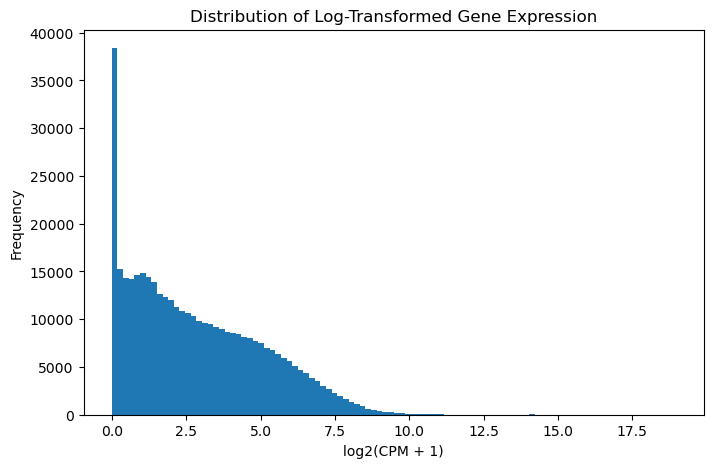

In [54]:
# Overall distribution of log-CPM values
plt.figure(figsize=(8, 5))

plt.hist(
    log_cpm.values.flatten(),
    bins=100
)

plt.xlabel("log2(CPM + 1)")
plt.ylabel("Frequency")
plt.title("Distribution of Log-Transformed Gene Expression")

plt.show()

/var/folders/0n/dpk0lv3553bfbmtc_53z_sth0000gn/T/ipykernel_19683/4141983920.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


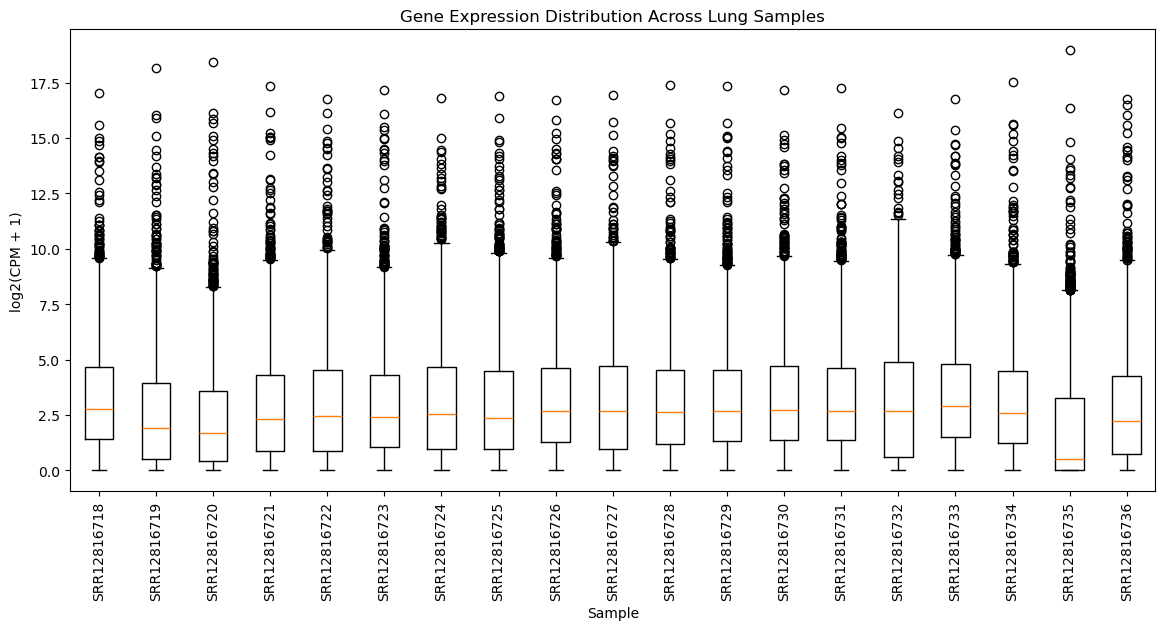

In [55]:
# Distribution of gene expression in each sample
plt.figure(figsize=(14, 6))

plt.boxplot(
    [log_cpm[sample] for sample in log_cpm.columns],
    labels=log_cpm.columns
)

plt.xlabel("Sample")
plt.ylabel("log2(CPM + 1)")
plt.title("Gene Expression Distribution Across Lung Samples")

plt.xticks(rotation=90)

plt.show()

In [56]:
sample_expression_summary = pd.DataFrame({
    "mean_log_cpm": log_cpm.mean(axis=0),
    "median_log_cpm": log_cpm.median(axis=0),
    "sd_log_cpm": log_cpm.std(axis=0)
})

sample_expression_summary

,mean_log_cpm,median_log_cpm,sd_log_cpm
SRR12816718,3.195581,2.781297,2.099565
SRR12816719,2.446079,1.914582,2.189555
SRR12816720,2.189445,1.707777,1.993211
SRR12816721,2.750923,2.307747,2.224425
SRR12816722,2.850969,2.449699,2.284428
SRR12816723,2.816229,2.395794,2.136202
SRR12816724,2.981153,2.537048,2.363277
SRR12816725,2.877996,2.354260,2.263577
SRR12816726,3.079915,2.690626,2.169420
SRR12816727,3.011336,2.686970,2.305973


In [57]:
sample_expression_summary.describe()

,mean_log_cpm,median_log_cpm,sd_log_cpm
count,19.000000,19.000000,19.000000
mean,2.854815,2.397495,2.195233
std,0.377016,0.544155,0.117718
min,1.740251,0.524274,1.993211
25%,2.783576,2.331004,2.122904
50%,2.983684,2.607006,2.169439
75%,3.077851,2.689874,2.244001
max,3.289744,2.922763,2.519543


In [58]:
from sklearn.decomposition import PCA

In [59]:
pca = PCA(n_components=2)

pca_components = pca.fit_transform(log_cpm.T)

pca_df = pd.DataFrame(
    pca_components,
    index=log_cpm.columns,
    columns=["PC1", "PC2"]
)

pca_df = pca_df.join(
    lung_metadata_aligned[["disease"]]
)

pca_df

,PC1,PC2,disease
SRR12816718,56.552676,16.478700,normal
SRR12816719,-83.891247,-52.838575,COVID-19
SRR12816720,-101.772860,-28.245860,COVID-19
SRR12816721,-25.966621,-38.424170,COVID-19
SRR12816722,-4.547192,-29.668041,COVID-19
SRR12816723,-15.981932,-31.705518,COVID-19
SRR12816724,4.768362,-59.994013,COVID-19
SRR12816725,-13.534382,-51.189082,COVID-19
SRR12816726,49.352531,19.160018,normal
SRR12816727,49.270589,36.944233,normal


In [60]:
pca.explained_variance_ratio_

array([0.34851803, 0.12563673])

In [61]:
print(f"PC1 explains {pca.explained_variance_ratio_[0] * 100:.2f}% of variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1] * 100:.2f}% of variance")

PC1 explains 34.85% of variance
PC2 explains 12.56% of variance


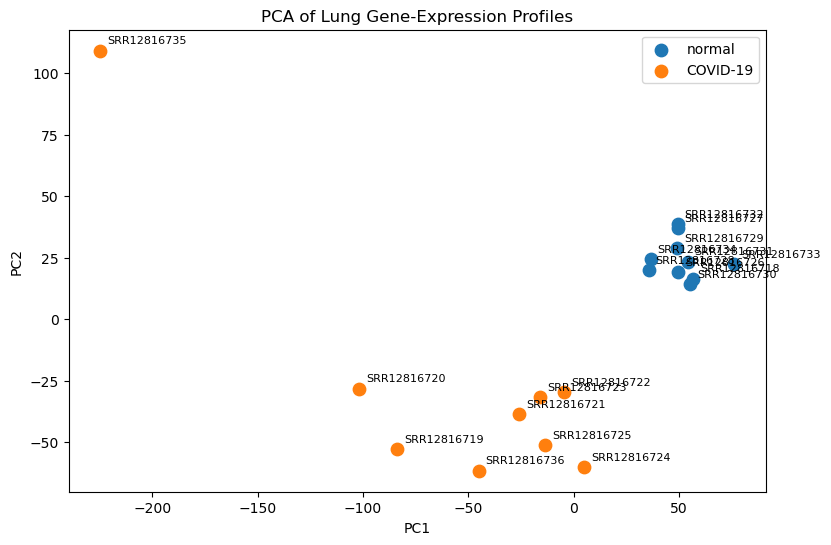

In [62]:
plt.figure(figsize=(9, 6))

for disease in pca_df["disease"].unique():
    subset = pca_df[pca_df["disease"] == disease]
    
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=disease,
        s=80
    )

for sample in pca_df.index:
    plt.annotate(
        sample,
        (pca_df.loc[sample, "PC1"], pca_df.loc[sample, "PC2"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Lung Gene-Expression Profiles")
plt.legend()
plt.show()

In [63]:
pca_group_summary = (
    pca_df
    .groupby("disease")[["PC1", "PC2"]]
    .agg(["mean", "std"])
)

pca_group_summary

PC1                   PC2           
               mean        std       mean        std
disease                                             
COVID-19 -56.744387  72.508141 -27.165098  52.695984
normal    51.069948  11.344528  24.448588   8.127440

In [64]:
pca_df.sort_values("PC1")

,PC1,PC2,disease
SRR12816735,-224.603402,109.093033,COVID-19
SRR12816720,-101.772860,-28.245860,COVID-19
SRR12816719,-83.891247,-52.838575,COVID-19
SRR12816736,-45.170206,-61.513659,COVID-19
SRR12816721,-25.966621,-38.424170,COVID-19
SRR12816723,-15.981932,-31.705518,COVID-19
SRR12816725,-13.534382,-51.189082,COVID-19
SRR12816722,-4.547192,-29.668041,COVID-19
SRR12816724,4.768362,-59.994013,COVID-19
SRR12816728,35.405636,19.981511,normal


In [65]:
pca_df.sort_values("PC2")

,PC1,PC2,disease
SRR12816736,-45.170206,-61.513659,COVID-19
SRR12816724,4.768362,-59.994013,COVID-19
SRR12816719,-83.891247,-52.838575,COVID-19
SRR12816725,-13.534382,-51.189082,COVID-19
SRR12816721,-25.966621,-38.424170,COVID-19
SRR12816723,-15.981932,-31.705518,COVID-19
SRR12816722,-4.547192,-29.668041,COVID-19
SRR12816720,-101.772860,-28.245860,COVID-19
SRR12816730,55.115961,14.282033,normal
SRR12816718,56.552676,16.478700,normal


In [66]:
pca_df.loc["SRR12816735"]

PC1       -224.603402
PC2        109.093033
disease      COVID-19
Name: SRR12816735, dtype: object

In [67]:
sample_expression_summary.loc["SRR12816735"]

mean_log_cpm      1.740251
median_log_cpm    0.524274
sd_log_cpm        2.207346
Name: SRR12816735, dtype: float64

In [68]:
covid_samples = lung_metadata_aligned[
    lung_metadata_aligned["disease"] == "COVID-19"
].index

sample_expression_summary.loc[covid_samples]

,mean_log_cpm,median_log_cpm,sd_log_cpm
SRR12816719,2.446079,1.914582,2.189555
SRR12816720,2.189445,1.707777,1.993211
SRR12816721,2.750923,2.307747,2.224425
SRR12816722,2.850969,2.449699,2.284428
SRR12816723,2.816229,2.395794,2.136202
SRR12816724,2.981153,2.537048,2.363277
SRR12816725,2.877996,2.354260,2.263577
SRR12816735,1.740251,0.524274,2.207346
SRR12816736,2.678439,2.249134,2.194268


In [69]:
sample_correlation = log_cpm.corr()

sample_correlation["SRR12816735"].sort_values()

SRR12816732    0.694170
SRR12816727    0.700731
SRR12816734    0.730191
SRR12816733    0.734570
SRR12816726    0.735281
SRR12816728    0.737361
SRR12816720    0.738393
SRR12816730    0.739447
SRR12816723    0.741016
SRR12816736    0.744162
SRR12816729    0.744902
SRR12816731    0.746852
SRR12816724    0.747463
SRR12816722    0.747798
SRR12816721    0.751650
SRR12816718    0.758184
SRR12816719    0.758444
SRR12816725    0.767563
SRR12816735    1.000000
Name: SRR12816735, dtype: float64

## Exploratory Analysis Findings

The exploratory analysis showed substantial variation across the 19 lung samples.

PCA revealed clear separation between COVID-19 and normal samples. The first two principal components explained 34.85% and 12.56% of the total variance, respectively, accounting for 47.41% combined.

Normal samples formed a relatively tight cluster, whereas COVID-19 samples showed greater dispersion. This suggests that disease status contributes to major variation in the lung gene-expression profiles in this dataset.

One COVID-19 sample, SRR12816735, was particularly distinct from the other samples. It had a lower overall expression level, with a mean log-CPM of 1.74 compared with the overall sample mean of 2.85, and was highly separated in PCA space.

Correlation analysis showed that SRR12816735 remained positively correlated with the other samples (approximately 0.69–0.77), so it was not automatically classified as a failed sample. Instead, it will be retained for the primary analysis and treated as a potentially influential observation.

These findings are exploratory and do not establish that COVID-19 causes the observed expression differences. Formal statistical analysis will be performed in the next stage.

## Differential Expression Analysis

The exploratory analysis identified substantial differences in the overall gene-expression profiles between COVID-19 and normal lung samples.

The next step is to examine individual genes and quantify whether their expression differs between the two groups.

The analysis compares nine COVID-19 lung samples with ten normal lung samples. For each retained gene, the difference in expression will be summarised using a log2 fold change and assessed statistically.

Because thousands of genes are tested simultaneously, raw p-values will be adjusted using the Benjamini-Hochberg procedure to control the false discovery rate.

This analysis uses log-transformed CPM values for an educational statistical comparison. It is not intended to replace specialised RNA-seq differential-expression methods such as DESeq2 or edgeR.

In [70]:
covid_samples = lung_metadata_aligned[
    lung_metadata_aligned["disease"] == "COVID-19"
].index.tolist()

normal_samples = lung_metadata_aligned[
    lung_metadata_aligned["disease"] == "normal"
].index.tolist()

print("COVID-19 samples:", len(covid_samples))
print("Normal samples:", len(normal_samples))

COVID-19 samples: 9
Normal samples: 10


In [71]:
print("COVID-19:")
print(covid_samples)

print("\nNormal:")
print(normal_samples)

COVID-19:
['SRR12816719', 'SRR12816720', 'SRR12816721', 'SRR12816722', 'SRR12816723', 'SRR12816724', 'SRR12816725', 'SRR12816735', 'SRR12816736']

Normal:
['SRR12816718', 'SRR12816726', 'SRR12816727', 'SRR12816728', 'SRR12816729', 'SRR12816730', 'SRR12816731', 'SRR12816732', 'SRR12816733', 'SRR12816734']


In [72]:
covid_mean = log_cpm[covid_samples].mean(axis=1)
normal_mean = log_cpm[normal_samples].mean(axis=1)

gene_expression_summary = pd.DataFrame({
    "covid_mean": covid_mean,
    "normal_mean": normal_mean
})

gene_expression_summary.head()

,covid_mean,normal_mean
Gene ID,,
ENSG00000000003,3.776399,4.390606
ENSG00000000005,0.350273,0.792069
ENSG00000000419,3.833670,3.707651
ENSG00000000457,3.253307,4.020048
ENSG00000000460,2.640107,3.725483


In [73]:
gene_expression_summary["mean_difference"] = (
    gene_expression_summary["covid_mean"]
    - gene_expression_summary["normal_mean"]
)

gene_expression_summary.head()

,covid_mean,normal_mean,mean_difference
Gene ID,,,
ENSG00000000003,3.776399,4.390606,-0.614207
ENSG00000000005,0.350273,0.792069,-0.441796
ENSG00000000419,3.833670,3.707651,0.126019
ENSG00000000457,3.253307,4.020048,-0.766742
ENSG00000000460,2.640107,3.725483,-1.085376


## Gene-Level Statistical Testing

For each gene, expression values were compared between the COVID-19 and normal lung samples using Welch's independent-samples t-test.

Welch's test was selected because it does not assume equal variance between the two groups, which is appropriate given the greater variability observed among the COVID-19 samples during exploratory analysis.

The resulting p-values indicate how compatible the observed group difference is with the null hypothesis of equal mean expression.

Because thousands of genes are tested simultaneously, statistical significance will subsequently be assessed using false-discovery-rate correction.

In [74]:
p_values = []

for gene in log_cpm.index:
    covid_values = log_cpm.loc[gene, covid_samples]
    normal_values = log_cpm.loc[gene, normal_samples]

    statistic, p_value = stats.ttest_ind(
        covid_values,
        normal_values,
        equal_var=False
    )

    p_values.append(p_value)

gene_expression_summary["p_value"] = p_values

gene_expression_summary.head()

,covid_mean,normal_mean,mean_difference,p_value
Gene ID,,,,
ENSG00000000003,3.776399,4.390606,-0.614207,0.322808
ENSG00000000005,0.350273,0.792069,-0.441796,0.100724
ENSG00000000419,3.833670,3.707651,0.126019,0.804188
ENSG00000000457,3.253307,4.020048,-0.766742,0.025989
ENSG00000000460,2.640107,3.725483,-1.085376,0.007004


In [75]:
gene_expression_summary.sort_values("p_value").head(10)

,covid_mean,normal_mean,mean_difference,p_value
Gene ID,,,,
ENSG00000226953,0.295579,3.253228,-2.957648,1.336144e-09
ENSG00000169218,0.738181,4.428330,-3.690149,3.659329e-09
ENSG00000235427,0.391111,3.346097,-2.954986,5.264245e-09
ENSG00000268416,0.490856,3.041527,-2.550671,8.077286e-09
ENSG00000180347,0.509244,2.641200,-2.131955,1.050350e-08
ENSG00000168517,0.115028,1.349768,-1.234741,1.205158e-08
ENSG00000248491,0.582004,3.431968,-2.849963,1.404326e-08
ENSG00000234763,0.260850,2.563011,-2.302161,1.638888e-08
ENSG00000257289,0.541577,1.791798,-1.250221,2.947789e-08


In [76]:
(gene_expression_summary["p_value"] < 0.05).sum()

np.int64(7750)

## Multiple-Testing Correction

Thousands of genes are tested simultaneously, so using an unadjusted p-value threshold of 0.05 would produce a substantial number of false-positive findings.

To account for multiple comparisons, the Benjamini-Hochberg procedure was used to calculate false-discovery-rate adjusted p-values.

The adjusted p-values provide a more appropriate basis for identifying genes with statistically supported differences in expression while controlling the expected proportion of false discoveries among the selected genes.

In [77]:
from statsmodels.stats.multitest import multipletests

In [78]:
gene_expression_summary["adjusted_p_value"] = multipletests(
    gene_expression_summary["p_value"],
    method="fdr_bh"
)[1]

In [79]:
gene_expression_summary.sort_values(
    "adjusted_p_value"
).head(20)

,covid_mean,normal_mean,mean_difference,p_value,adjusted_p_value
Gene ID,,,,,
ENSG00000226953,0.295579,3.253228,-2.957648,1.336144e-09,0.000028
ENSG00000169218,0.738181,4.428330,-3.690149,3.659329e-09,0.000037
ENSG00000235427,0.391111,3.346097,-2.954986,5.264245e-09,0.000037
ENSG00000180347,0.509244,2.641200,-2.131955,1.050350e-08,0.000042
ENSG00000168517,0.115028,1.349768,-1.234741,1.205158e-08,0.000042
ENSG00000248491,0.582004,3.431968,-2.849963,1.404326e-08,0.000042
ENSG00000268416,0.490856,3.041527,-2.550671,8.077286e-09,0.000042
ENSG00000234763,0.260850,2.563011,-2.302161,1.638888e-08,0.000043
ENSG00000197658,0.063304,1.475843,-1.412539,2.972682e-08,0.000062


In [80]:
(
    gene_expression_summary["adjusted_p_value"] < 0.05
).sum()

np.int64(4425)

In [81]:
print(
    "Raw p < 0.05:",
    (gene_expression_summary["p_value"] < 0.05).sum()
)

print(
    "Adjusted p < 0.05:",
    (gene_expression_summary["adjusted_p_value"] < 0.05).sum()
)

Raw p < 0.05: 7750
Adjusted p < 0.05: 4425


In [82]:
gene_expression_summary = gene_expression_summary.rename(
    columns={"mean_difference": "log2_fold_change"}
)

In [83]:
gene_expression_summary.sort_values(
    "log2_fold_change",
    ascending=False
).head(10)

,covid_mean,normal_mean,log2_fold_change,p_value,adjusted_p_value
Gene ID,,,,,
ENSG00000137558,7.817634,3.179899,4.637734,0.000119,0.003892
ENSG00000163661,6.112458,2.078126,4.034332,0.003079,0.024058
ENSG00000205420,3.806668,0.004814,3.801854,0.000759,0.011011
ENSG00000118785,5.446738,1.735963,3.710775,0.000320,0.006678
ENSG00000168542,11.144889,7.657699,3.487189,0.000337,0.006894
ENSG00000135919,5.252746,1.767767,3.484979,0.000175,0.004771
ENSG00000108821,9.739528,6.263479,3.476049,0.000731,0.010838
ENSG00000143546,6.317896,2.868729,3.449167,0.000033,0.001942
ENSG00000188257,4.781188,1.374108,3.407080,0.000031,0.001842


In [84]:
gene_expression_summary.sort_values(
    "log2_fold_change",
    ascending=True
).head(10)

,covid_mean,normal_mean,log2_fold_change,p_value,adjusted_p_value
Gene ID,,,,,
ENSG00000125740,1.700382,7.681130,-5.980748,3.370094e-08,0.000064
ENSG00000182010,4.014110,9.191416,-5.177305,2.213155e-07,0.000138
ENSG00000229807,4.389139,9.042382,-4.653243,2.624816e-02,0.088378
ENSG00000168484,2.961757,7.529606,-4.567849,9.426154e-05,0.003432
ENSG00000176771,2.249792,6.749325,-4.499532,1.279498e-05,0.001148
ENSG00000204305,2.855953,7.083668,-4.227715,3.750056e-05,0.002069
ENSG00000155511,0.915057,4.983330,-4.068273,1.288203e-07,0.000109
ENSG00000273540,0.158473,4.222501,-4.064028,1.203664e-06,0.000308
ENSG00000066405,4.449056,8.362135,-3.913078,3.813828e-04,0.007446


In [85]:
gene_expression_summary["fold_change"] = (
    2 ** gene_expression_summary["log2_fold_change"]
)

In [86]:
gene_expression_summary.sort_values(
    "adjusted_p_value"
).head(20)

,covid_mean,normal_mean,log2_fold_change,p_value,adjusted_p_value,fold_change
Gene ID,,,,,,
ENSG00000226953,0.295579,3.253228,-2.957648,1.336144e-09,0.000028,0.128724
ENSG00000169218,0.738181,4.428330,-3.690149,3.659329e-09,0.000037,0.077474
ENSG00000235427,0.391111,3.346097,-2.954986,5.264245e-09,0.000037,0.128962
ENSG00000180347,0.509244,2.641200,-2.131955,1.050350e-08,0.000042,0.228148
ENSG00000168517,0.115028,1.349768,-1.234741,1.205158e-08,0.000042,0.424919
ENSG00000248491,0.582004,3.431968,-2.849963,1.404326e-08,0.000042,0.138700
ENSG00000268416,0.490856,3.041527,-2.550671,8.077286e-09,0.000042,0.170676
ENSG00000234763,0.260850,2.563011,-2.302161,1.638888e-08,0.000043,0.202759
ENSG00000197658,0.063304,1.475843,-1.412539,2.972682e-08,0.000062,0.375650


In [87]:
gene_expression_summary = gene_expression_summary.join(
    gene_annotations.rename(columns={"Gene Name": "gene_name"})
)

In [88]:
gene_expression_summary.head()

,covid_mean,normal_mean,log2_fold_change,p_value,adjusted_p_value,fold_change,gene_name
Gene ID,,,,,,,
ENSG00000000003,3.776399,4.390606,-0.614207,0.322808,0.474645,0.653289,TSPAN6
ENSG00000000005,0.350273,0.792069,-0.441796,0.100724,0.214893,0.736217,TNMD
ENSG00000000419,3.833670,3.707651,0.126019,0.804188,0.875533,1.091278,DPM1
ENSG00000000457,3.253307,4.020048,-0.766742,0.025989,0.087883,0.587743,SCYL3
ENSG00000000460,2.640107,3.725483,-1.085376,0.007004,0.038695,0.471269,C1orf112


In [89]:
gene_expression_summary.sort_values(
    "adjusted_p_value"
).head(20)

,covid_mean,normal_mean,log2_fold_change,p_value,adjusted_p_value,fold_change,gene_name
Gene ID,,,,,,,
ENSG00000226953,0.295579,3.253228,-2.957648,1.336144e-09,0.000028,0.128724,NCKAP5-AS2
ENSG00000169218,0.738181,4.428330,-3.690149,3.659329e-09,0.000037,0.077474,RSPO1
ENSG00000235427,0.391111,3.346097,-2.954986,5.264245e-09,0.000037,0.128962,NaN
ENSG00000180347,0.509244,2.641200,-2.131955,1.050350e-08,0.000042,0.228148,ITPRID1
ENSG00000168517,0.115028,1.349768,-1.234741,1.205158e-08,0.000042,0.424919,HEXIM2
ENSG00000248491,0.582004,3.431968,-2.849963,1.404326e-08,0.000042,0.138700,NaN
ENSG00000268416,0.490856,3.041527,-2.550671,8.077286e-09,0.000042,0.170676,NaN
ENSG00000234763,0.260850,2.563011,-2.302161,1.638888e-08,0.000043,0.202759,NaN
ENSG00000197658,0.063304,1.475843,-1.412539,2.972682e-08,0.000062,0.375650,SLC22A24


In [90]:
significant_genes = gene_expression_summary[
    (gene_expression_summary["adjusted_p_value"] < 0.05) &
    (gene_expression_summary["log2_fold_change"].abs() >= 1)
].copy()

print("Significant genes:", len(significant_genes))

Significant genes: 3047


In [91]:
upregulated_genes = significant_genes[
    significant_genes["log2_fold_change"] >= 1
].sort_values("log2_fold_change", ascending=False)

downregulated_genes = significant_genes[
    significant_genes["log2_fold_change"] <= -1
].sort_values("log2_fold_change", ascending=True)

In [92]:
upregulated_genes.head(10)

,covid_mean,normal_mean,log2_fold_change,p_value,adjusted_p_value,fold_change,gene_name
Gene ID,,,,,,,
ENSG00000137558,7.817634,3.179899,4.637734,0.000119,0.003892,24.894138,PI15
ENSG00000163661,6.112458,2.078126,4.034332,0.003079,0.024058,16.385318,PTX3
ENSG00000205420,3.806668,0.004814,3.801854,0.000759,0.011011,13.946724,KRT6A
ENSG00000118785,5.446738,1.735963,3.710775,0.000320,0.006678,13.093467,SPP1
ENSG00000168542,11.144889,7.657699,3.487189,0.000337,0.006894,11.213689,COL3A1
ENSG00000135919,5.252746,1.767767,3.484979,0.000175,0.004771,11.196523,SERPINE2
ENSG00000108821,9.739528,6.263479,3.476049,0.000731,0.010838,11.127434,COL1A1
ENSG00000143546,6.317896,2.868729,3.449167,0.000033,0.001942,10.922012,S100A8
ENSG00000188257,4.781188,1.374108,3.407080,0.000031,0.001842,10.607994,PLA2G2A


In [93]:
downregulated_genes.head(10)

,covid_mean,normal_mean,log2_fold_change,p_value,adjusted_p_value,fold_change,gene_name
Gene ID,,,,,,,
ENSG00000125740,1.700382,7.681130,-5.980748,3.370094e-08,0.000064,0.015835,FOSB
ENSG00000182010,4.014110,9.191416,-5.177305,2.213155e-07,0.000138,0.027636,RTKN2
ENSG00000168484,2.961757,7.529606,-4.567849,9.426154e-05,0.003432,0.042164,SFTPC
ENSG00000176771,2.249792,6.749325,-4.499532,1.279498e-05,0.001148,0.044208,NCKAP5
ENSG00000204305,2.855953,7.083668,-4.227715,3.750056e-05,0.002069,0.053374,AGER
ENSG00000155511,0.915057,4.983330,-4.068273,1.288203e-07,0.000109,0.059611,GRIA1
ENSG00000273540,0.158473,4.222501,-4.064028,1.203664e-06,0.000308,0.059787,AGBL1
ENSG00000066405,4.449056,8.362135,-3.913078,3.813828e-04,0.007446,0.066381,CLDN18
ENSG00000149534,2.133924,6.036314,-3.902390,1.470942e-04,0.004311,0.066875,MS4A2


## Differential Expression Visualisation

A volcano plot was used to visualise the relationship between effect size and statistical evidence across the analysed genes.

The x-axis represents the log2 fold change between COVID-19 and normal lung samples, while the y-axis represents the negative log10 of the Benjamini-Hochberg adjusted p-value.

Genes further from zero have larger observed expression differences, while genes higher on the plot have stronger statistical evidence.

The plot provides an overview of the genes contributing to the differential-expression signal rather than focusing only on the smallest p-values.

In [94]:
plot_data = gene_expression_summary.copy()

plot_data["minus_log10_adjusted_p"] = -np.log10(
    plot_data["adjusted_p_value"]
)

plot_data["significant"] = (
    (plot_data["adjusted_p_value"] < 0.05) &
    (plot_data["log2_fold_change"].abs() >= 1)
)

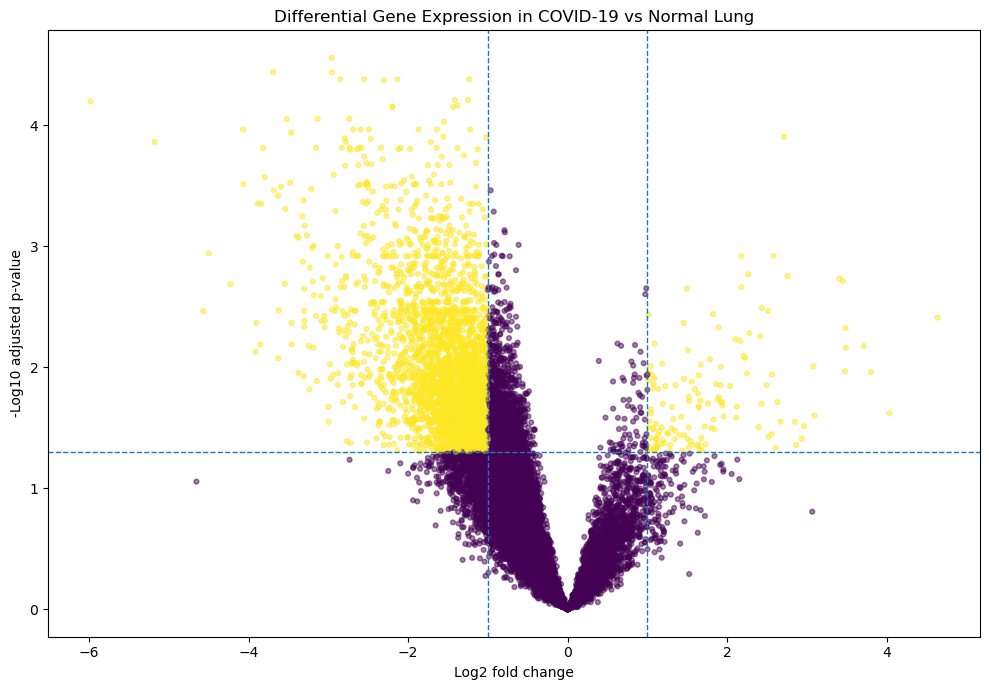

In [95]:
plt.figure(figsize=(10, 7))

plt.scatter(
    plot_data["log2_fold_change"],
    plot_data["minus_log10_adjusted_p"],
    c=plot_data["significant"],
    alpha=0.5,
    s=12
)

plt.axvline(1, linestyle="--", linewidth=1)
plt.axvline(-1, linestyle="--", linewidth=1)
plt.axhline(
    -np.log10(0.05),
    linestyle="--",
    linewidth=1
)

plt.xlabel("Log2 fold change")
plt.ylabel("-Log10 adjusted p-value")
plt.title("Differential Gene Expression in COVID-19 vs Normal Lung")

plt.tight_layout()
plt.show()

In [96]:
gene_expression_summary["minus_log10_adjusted_p"] = -np.log10(
    gene_expression_summary["adjusted_p_value"]
)

gene_expression_summary["significant"] = (
    (gene_expression_summary["adjusted_p_value"] < 0.05) &
    (gene_expression_summary["log2_fold_change"].abs() >= 1)
)

In [97]:
significant_genes = gene_expression_summary[
    gene_expression_summary["significant"]
].copy()

upregulated_genes = significant_genes[
    significant_genes["log2_fold_change"] >= 1
].sort_values(
    "log2_fold_change",
    ascending=False
)

downregulated_genes = significant_genes[
    significant_genes["log2_fold_change"] <= -1
].sort_values(
    "log2_fold_change",
    ascending=True
)

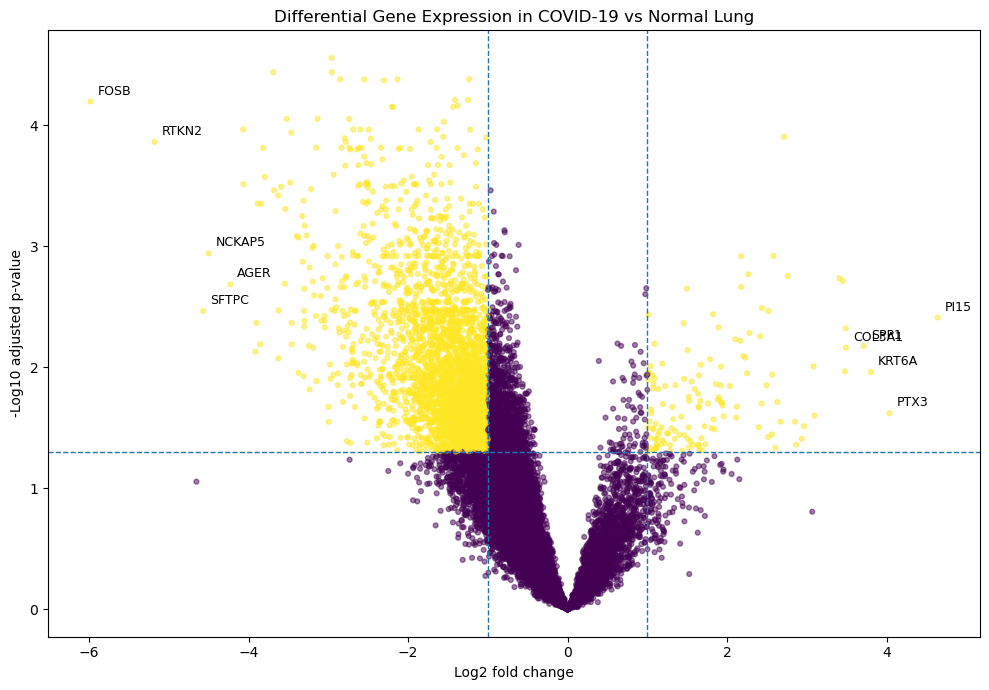

In [98]:
top_up = upregulated_genes.head(5)
top_down = downregulated_genes.head(5)

plt.figure(figsize=(10, 7))

plt.scatter(
    gene_expression_summary["log2_fold_change"],
    gene_expression_summary["minus_log10_adjusted_p"],
    c=gene_expression_summary["significant"],
    alpha=0.5,
    s=12
)

plt.axvline(1, linestyle="--", linewidth=1)
plt.axvline(-1, linestyle="--", linewidth=1)
plt.axhline(
    -np.log10(0.05),
    linestyle="--",
    linewidth=1
)

for gene_id, row in pd.concat([top_up, top_down]).iterrows():
    if pd.notna(row["gene_name"]):
        plt.annotate(
            row["gene_name"],
            (row["log2_fold_change"], row["minus_log10_adjusted_p"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )

plt.xlabel("Log2 fold change")
plt.ylabel("-Log10 adjusted p-value")
plt.title("Differential Gene Expression in COVID-19 vs Normal Lung")

plt.tight_layout()
plt.show()

## Differential Expression Findings

The differential-expression analysis identified 3,047 genes meeting the predefined criteria of an adjusted p-value below 0.05 and an absolute log2 fold change of at least 1.

The volcano plot shows a substantial number of genes with statistically supported differences in expression between COVID-19 and normal lung samples. The strongest signals were more prominent on the negative log2 fold-change side, indicating lower observed expression in COVID-19 samples for many of the most statistically supported genes.

Among the genes with higher observed expression in COVID-19 samples were PI15, PTX3, KRT6A, SPP1, COL3A1, COL1A1, S100A8 and S100A12. Among the genes with lower observed expression were FOSB, RTKN2, SFTPC, NCKAP5, AGER and CLDN18.

These findings describe statistical differences in this dataset and should not be interpreted as evidence that COVID-19 directly causes changes in individual genes. The analysis uses log-transformed CPM values and Welch's t-tests rather than specialised RNA-seq differential-expression models such as DESeq2 or edgeR. The relatively small sample size and the presence of an unusual COVID-19 sample identified during PCA are additional limitations.

In [99]:
print("Total significant genes:", len(significant_genes))
print("Upregulated genes:", len(upregulated_genes))
print("Downregulated genes:", len(downregulated_genes))

Total significant genes: 3047
Upregulated genes: 136
Downregulated genes: 2911


## Statistical Findings

The analysis compared gene expression between nine COVID-19 and ten normal lung samples.

Of the 20,813 genes retained after preprocessing, 3,047 met both predefined criteria for differential expression: a Benjamini-Hochberg adjusted p-value below 0.05 and an absolute log2 fold change of at least 1.

Among these genes, 136 showed higher observed expression in the COVID-19 group and 2,911 showed lower observed expression.

The strongest higher-expression signals included PI15, PTX3, KRT6A, SPP1, COL3A1, COL1A1, S100A8 and S100A12. Strong lower-expression signals included FOSB, RTKN2, SFTPC, NCKAP5, AGER and CLDN18.

The large imbalance between genes with higher and lower observed expression is notable, but it should not be interpreted as evidence of global biological downregulation. Bulk tissue composition, sample-level variation and the statistical approach used here may contribute to the observed pattern.

The results should therefore be interpreted as exploratory evidence of gene-expression differences within this dataset rather than as definitive biological or clinical findings.

## Sensitivity Analysis

One COVID-19 sample, SRR12816735, showed an unusual position in PCA space and a lower overall expression level than the other samples.

The sample was retained in the primary analysis because correlation analysis showed positive relationships with the other samples and there was no clear evidence that it represented a failed sequencing run.

As a sensitivity analysis, the differential-expression procedure was repeated after temporarily excluding this sample. This was used to assess whether the overall findings were strongly dependent on a single observation.

The primary analysis remains the analysis including all 19 lung samples.

In [100]:
covid_samples_sensitivity = [
    sample for sample in covid_samples
    if sample != "SRR12816735"
]

p_values_sensitivity = []

covid_mean_sensitivity = log_cpm[covid_samples_sensitivity].mean(axis=1)
normal_mean_sensitivity = log_cpm[normal_samples].mean(axis=1)

log2fc_sensitivity = (
    covid_mean_sensitivity - normal_mean_sensitivity
)

for gene in log_cpm.index:
    covid_values = log_cpm.loc[gene, covid_samples_sensitivity]
    normal_values = log_cpm.loc[gene, normal_samples]

    statistic, p_value = stats.ttest_ind(
        covid_values,
        normal_values,
        equal_var=False
    )

    p_values_sensitivity.append(p_value)

sensitivity_results = pd.DataFrame({
    "covid_mean": covid_mean_sensitivity,
    "normal_mean": normal_mean_sensitivity,
    "log2_fold_change": log2fc_sensitivity,
    "p_value": p_values_sensitivity
})

sensitivity_results["adjusted_p_value"] = multipletests(
    sensitivity_results["p_value"],
    method="fdr_bh"
)[1]

sensitivity_results["significant"] = (
    (sensitivity_results["adjusted_p_value"] < 0.05) &
    (sensitivity_results["log2_fold_change"].abs() >= 1)
)

print(
    "Sensitivity significant genes:",
    sensitivity_results["significant"].sum()
)

Sensitivity significant genes: 2631


In [101]:
print(
    "Primary significant genes:",
    len(significant_genes)
)

print(
    "Sensitivity significant genes:",
    sensitivity_results["significant"].sum()
)

Primary significant genes: 3047
Sensitivity significant genes: 2631


## Expression Patterns of Top Differentially Expressed Genes

A heatmap was used to visualise expression patterns for the 20 genes with the smallest adjusted p-values.

Expression values were standardised within each gene for visualisation. This allows relative expression patterns across samples to be compared even when genes have very different absolute expression levels.

The heatmap is intended as an exploratory visualisation and does not represent an additional statistical test.

In [103]:
top_20_genes = gene_expression_summary.sort_values(
    "adjusted_p_value"
).head(20)

heatmap_data = log_cpm.loc[
    top_20_genes.index,
    lung_metadata_aligned.index
].copy()

heatmap_data.index = [
    gene_name if pd.notna(gene_name) else gene_id
    for gene_id, gene_name in zip(
        top_20_genes.index,
        top_20_genes["gene_name"]
    )
]

heatmap_z = heatmap_data.sub(
    heatmap_data.mean(axis=1),
    axis=0
).div(
    heatmap_data.std(axis=1),
    axis=0
)

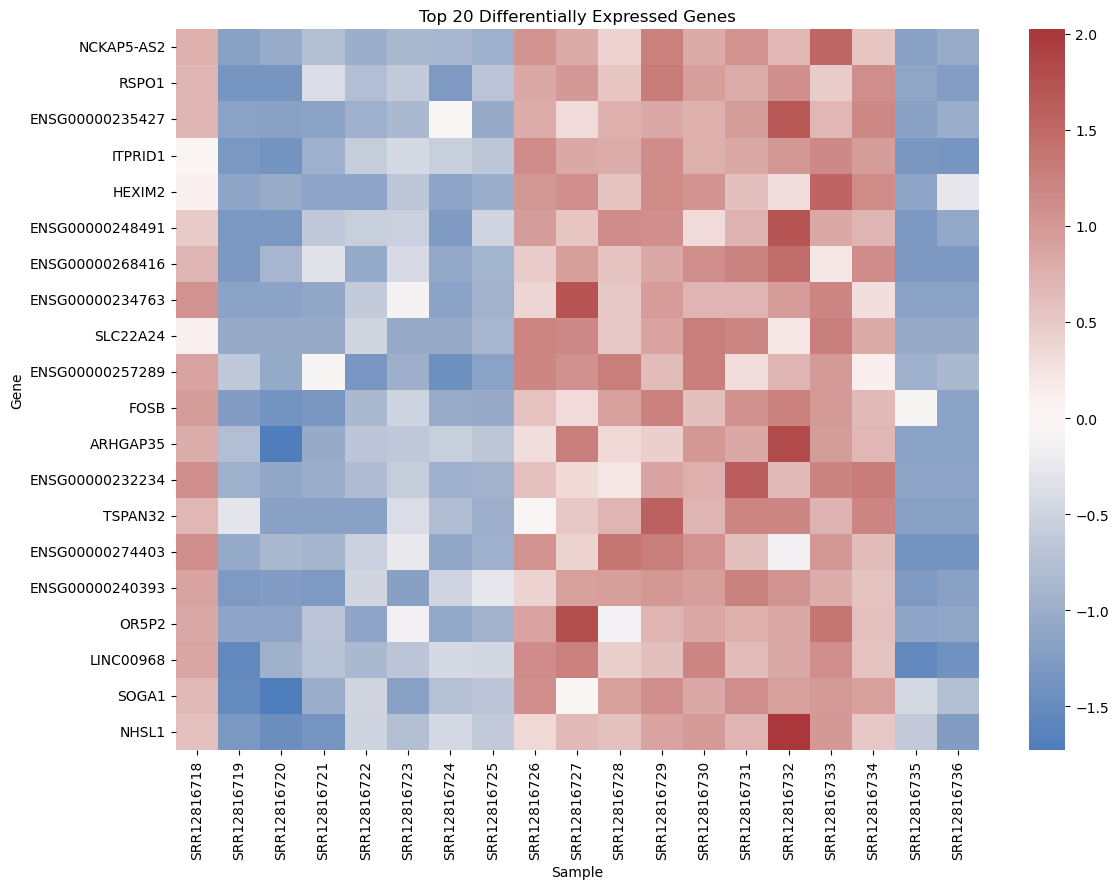

In [104]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    heatmap_z,
    cmap="vlag",
    center=0,
    xticklabels=True,
    yticklabels=True
)

plt.xlabel("Sample")
plt.ylabel("Gene")
plt.title("Top 20 Differentially Expressed Genes")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Sensitivity Analysis Findings

Excluding the potentially influential COVID-19 sample SRR12816735 reduced the number of genes meeting the predefined differential-expression criteria from 3,047 to 2,631.

The reduction indicates that SRR12816735 has some influence on the magnitude of the statistical findings. However, a large number of genes remained significant after its exclusion.

This suggests that the overall differential-expression signal is not dependent entirely on a single sample. The primary analysis therefore retains all 19 lung samples, while the sensitivity analysis provides additional context for interpreting the robustness of the findings.

## Biological Interpretation

The differential-expression results showed a pattern involving both inflammatory and tissue-associated genes.

Several genes with higher observed expression in COVID-19 lung samples have established roles in inflammatory or immune-related processes. PTX3 is involved in innate immune and inflammatory responses, while S100A8 and S100A12 are associated with inflammatory signalling and leukocyte recruitment. SPP1 is also involved in immune regulation and tissue responses. These findings are consistent with an inflammatory component in the transcriptional profiles of the COVID-19 lung samples.

Several extracellular-matrix-associated genes, including COL1A1 and COL3A1, also showed higher expression in the COVID-19 group. These genes encode structural collagen components of the extracellular matrix. Their increased expression may be consistent with tissue-remodelling processes, although the present analysis cannot determine the underlying cellular source or mechanism.

Conversely, SFTPC and AGER were among the genes with strongly reduced expression in COVID-19 samples. SFTPC encodes pulmonary surfactant protein C and is associated with alveolar lung function, while AGER is highly expressed in lung tissue and encodes a receptor involved in cellular signalling and inflammation.

Taken together, the results suggest that the COVID-19 lung samples in this dataset display differences involving inflammatory, extracellular-matrix and lung epithelial-associated transcriptional programs.

These observations are associations within post-mortem bulk tissue samples. They do not establish that COVID-19 directly caused the expression changes, nor can they distinguish altered cellular composition from altered gene regulation within individual cell types.

## Limitations

Several limitations should be considered when interpreting these results.

- The lung analysis included only 19 samples: nine COVID-19 and ten normal controls.
- The data represent post-mortem tissue from fatal COVID-19 cases and therefore may not represent mild, moderate or surviving COVID-19 infection.
- The analysis used bulk lung tissue, so differences in cell-type composition may contribute to observed gene-expression differences.
- The statistical analysis used log2-transformed CPM values and Welch's t-tests. This is an educational approach and is not equivalent to specialised RNA-seq differential-expression methods such as DESeq2, edgeR or limma-voom.
- No multivariable model was used to adjust for potential biological or technical covariates.
- One COVID-19 sample, SRR12816735, showed unusual behaviour in PCA and was retained in the primary analysis. A sensitivity analysis was performed to assess its potential influence.
- The analysis identifies statistical associations rather than causal relationships.
- Genes with missing gene-name annotations were retained using their Ensembl identifiers.
- The findings require validation in independent datasets and, where appropriate, experimental studies.

## Conclusion

This analysis investigated gene-expression differences between COVID-19 and normal lung samples using the E-ENAD-46 RNA-seq dataset.

After preprocessing, 20,813 genes were retained for exploratory and statistical analysis. PCA showed substantial separation between the COVID-19 and normal samples, while differential-expression analysis identified 3,047 genes meeting the predefined criteria of adjusted p-value below 0.05 and absolute log2 fold change of at least 1.

The strongest signals included increased expression of inflammatory and extracellular-matrix-associated genes such as PTX3, S100A8, S100A12, SPP1, COL1A1 and COL3A1, alongside reduced expression of genes including SFTPC and AGER that are associated with lung epithelial biology.

Overall, the analysis demonstrates how RNA-seq data can be processed and explored using Python, from raw count inspection and normalisation through PCA, statistical testing, multiple-testing correction and biological interpretation.

The findings are exploratory and should not be interpreted as definitive evidence of disease mechanisms. More specialised RNA-seq models, larger cohorts, independent validation datasets and cell-type-specific analyses would be appropriate for further investigation.

## References and Data Sources

- E-ENAD-46: Lung and colon transcriptome profiling of fatal COVID-19 cases, EMBL-EBI Expression Atlas.
- Wu M, Chen Y, Xia H, et al. Transcriptional and proteomic insights into the host response in fatal COVID-19 cases. Proceedings of the National Academy of Sciences. 2020;117(44):28287–28295.
- National Center for Biotechnology Information (NCBI) Gene database for gene-function annotations.

## Analysis Summary

| Stage | Approach |
|---|---|
| Tissue selection | Lung samples only |
| Samples | 9 COVID-19, 10 normal |
| Initial genes | 58,735 |
| Genes after filtering | 20,813 |
| Normalisation | Counts per million (CPM) |
| Transformation | log2(CPM + 1) |
| Exploratory analysis | PCA |
| Gene-level test | Welch's independent-samples t-test |
| Multiple-testing correction | Benjamini-Hochberg FDR |
| Differential-expression threshold | Adjusted p < 0.05 and \|log2FC\| ≥ 1 |
| Sensitivity analysis | Exclusion of SRR12816735 |
| Main visualisations | PCA, volcano plot, heatmap |